Grid size: I=40, J=40


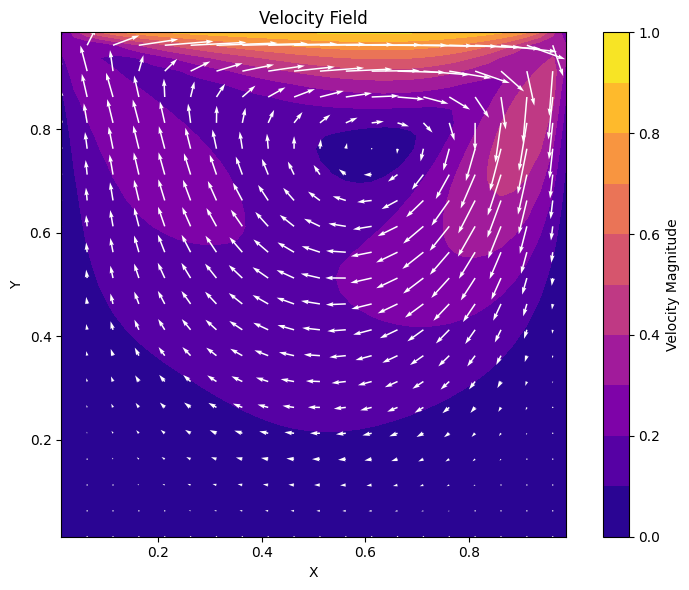

In [41]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


filename = "case_data/0_quick2/0_result.dat"
filename ='case_data/0_uds2/snaps/snap_000400.dat'
# Read file
with open(filename, "r") as f:
    lines = f.readlines()

# Extract I and J from ZONE line
zone_line = [line for line in lines if "ZONE" in line][0]
I = int(re.search(r"I=\s*(\d+)", zone_line).group(1))
J = int(re.search(r"J=\s*(\d+)", zone_line).group(1))

print(f"Grid size: I={I}, J={J}")

# Find where numeric data starts
data_start = 0
for i, line in enumerate(lines):
    if re.match(r"\s*[-+0-9.]", line):
        data_start = i
        break

# Load numerical data
df = pd.read_csv(
    filename,
    sep=r"\s+",
    skiprows=data_start,
    names=["X", "Y", "U", "V", "P"],
    engine="python"
)

# Reshape into grid
X = df["X"].values.reshape(J, I)
Y = df["Y"].values.reshape(J, I)
U = df["U"].values.reshape(J, I)
V = df["V"].values.reshape(J, I)

velocity_mag = np.sqrt(U**2 + V**2)
# --------- PLOTTING ---------
plt.figure(figsize=(8,6))

# Contour plot of velocity magnitude
contour = plt.contourf(X, Y, velocity_mag, levels=10, cmap="plasma")
plt.colorbar(contour, label="Velocity Magnitude")

# Quiver plot (velocity vectors)
step=2
plt.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    U[::step, ::step],
    V[::step, ::step],
    color="white",
    scale=5
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Velocity Field")
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()


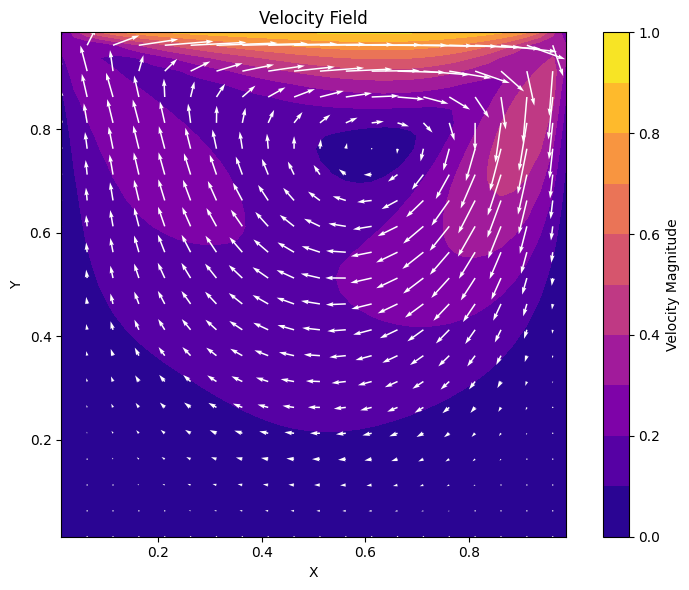

In [42]:
# --------- PLOTTING ---------
plt.figure(figsize=(8,6))

# Contour plot of velocity magnitude
contour = plt.contourf(X, Y, velocity_mag, levels=10, cmap="plasma")
plt.colorbar(contour, label="Velocity Magnitude")

# Quiver plot (velocity vectors)
step=2
plt.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    U[::step, ::step],
    V[::step, ::step],
    color="white",
    scale=5
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Velocity Field")
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()


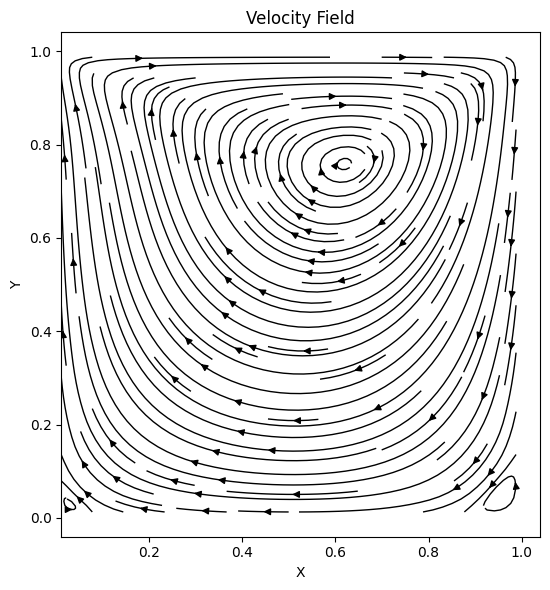

In [43]:
# --------- PLOTTING ---------
plt.figure(figsize=(8,6))

# Contour plot of velocity magnitude

# Streamlines
plt.streamplot(
    X, Y, U, V,
    color="black",      # streamline color
    density=1.5,        # controls number of lines
    linewidth=1
)


plt.xlabel("X")
plt.ylabel("Y")
plt.title("Velocity Field")
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()

/var/folders/dz/13jyqy9s2pj6nzzr5q4x48nw0000gn/T/ipykernel_10498/4223830620.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


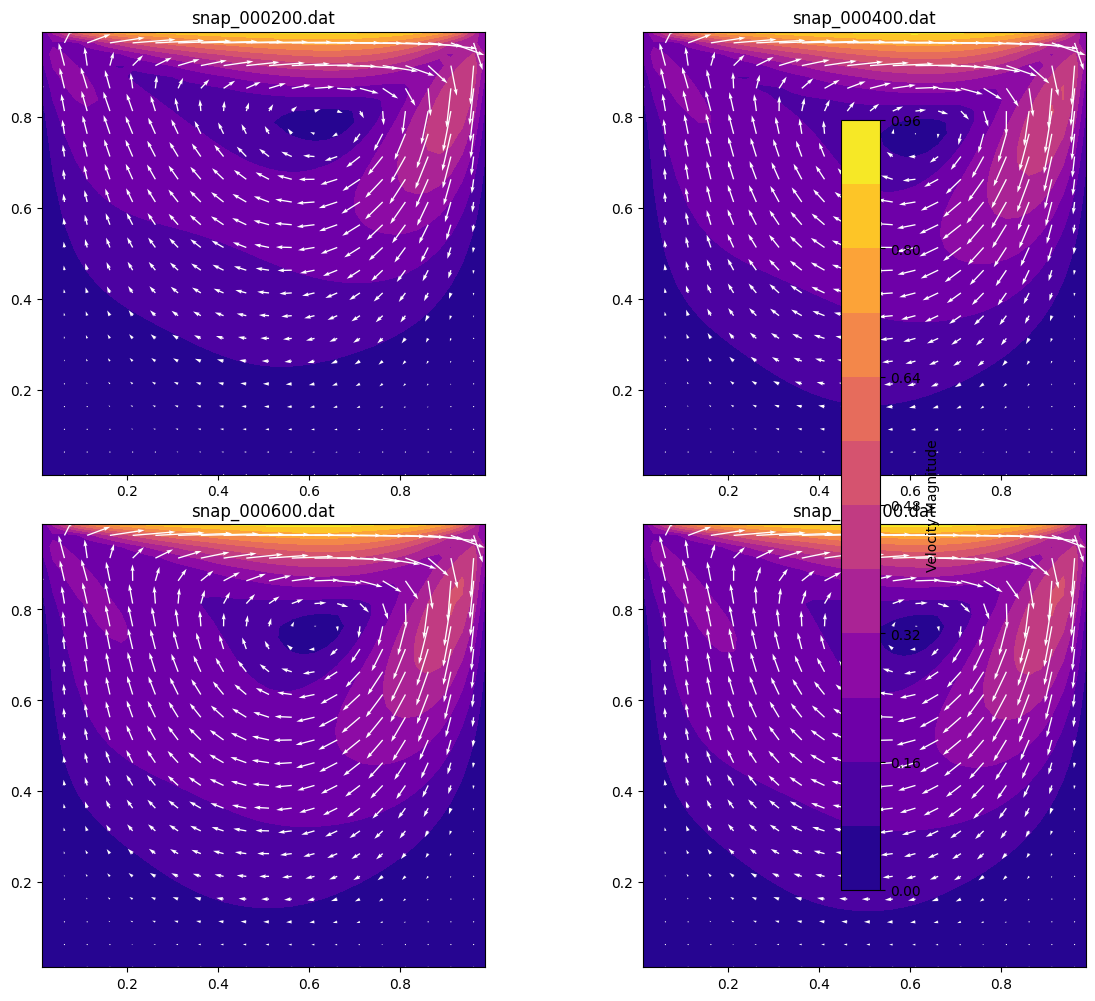

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr
# ---------------------------------------------------------
# Helper: load a Tecplot-style snapshot file
# ---------------------------------------------------------
def load_snapshot(fname):
    with open(fname, "r") as f:
        lines = f.readlines()

    # Extract I, J from ZONE line
    zone_line = [line for line in lines if "ZONE" in line][0]
    I = int(re.search(r"I=\s*(\d+)", zone_line).group(1))
    J = int(re.search(r"J=\s*(\d+)", zone_line).group(1))

    # Find numeric data start
    data_start = next(i for i, line in enumerate(lines)
                      if re.match(r"\s*[-+0-9.]", line))

    # Load data
    df = pd.read_csv(
        fname,
        sep=r"\s+",
        skiprows=data_start,
        names=["X", "Y", "U", "V", "P"],
        engine="python"
    )

    # Reshape into grids
    X = df["X"].values.reshape(J, I)
    Y = df["Y"].values.reshape(J, I)
    U = df["U"].values.reshape(J, I)
    V = df["V"].values.reshape(J, I)
    vel = np.sqrt(U**2 + V**2)

    return X, Y, U, V, vel


# ---------------------------------------------------------
# Helper: plot one snapshot into a given axis
# ---------------------------------------------------------
def plot_snapshot(ax, X, Y, U, V, vel, title=None):
    contour = ax.contourf(X, Y, vel, levels=12, cmap="plasma")

    step = 2
    ax.quiver(
        X[::step, ::step],
        Y[::step, ::step],
        U[::step, ::step],
        V[::step, ::step],
        color="white",
        scale=5
    )

    ax.set_aspect("equal")
    if title:
        ax.set_title(title)

    return contour


# ---------------------------------------------------------
# Choose snapshots to plot
# ---------------------------------------------------------
snap_dir = Path("case_data/0_uds2/snaps")
snap_files = sorted(snap_dir.glob("snap_*.dat"))

# Pick snapshots (example: first 4)
selected = snap_files[:4]

# ---------------------------------------------------------
# Build multi-panel figure
# ---------------------------------------------------------
n = len(selected)
cols = 2
rows = (n + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 10))
axes = axes.ravel()

last_contour = None

for ax, fname in zip(axes, selected):
    X, Y, U, V, vel = load_snapshot(fname)
    last_contour = plot_snapshot(ax, X, Y, U, V, vel, title=fname.name)

# Hide unused axes if any
for ax in axes[n:]:
    ax.axis("off")

# Shared colorbar
fig.colorbar(last_contour, ax=axes.tolist(), label="Velocity Magnitude")

plt.tight_layout()
plt.show()


In [45]:
snap_dir = Path("case_data/0_uds2/snaps")   # folder containing snap_*.dat
pattern = "snap_*.dat"
NLEVELS = 20
QUIVER_STEP = 3
def load_snapshot(fname):
    with open(fname, "r") as f:
        lines = f.readlines()

    # Extract I, J
    zone_line = [line for line in lines if "ZONE" in line][0]
    I = int(re.search(r"I=\s*(\d+)", zone_line).group(1))
    J = int(re.search(r"J=\s*(\d+)", zone_line).group(1))

    # Find numeric data start
    data_start = next(i for i, line in enumerate(lines)
                      if re.match(r"\s*[-+0-9.]", line))

    # Load data
    arr = np.loadtxt(fname, skiprows=data_start)
    X = arr[:,0].reshape(J, I)
    Y = arr[:,1].reshape(J, I)
    U = arr[:,2].reshape(J, I)
    V = arr[:,3].reshape(J, I)
    P = arr[:,4].reshape(J, I)

    return xr.Dataset(
        {
            "U": (("j","i"), U),
            "V": (("j","i"), V),
            "P": (("j","i"), P),
            "velmag": (("j","i"), np.sqrt(U**2 + V**2))
        },
        coords={"X": (("j","i"), X),
                "Y": (("j","i"), Y)}
    )

# -----------------------------
# Load all snapshots
# -----------------------------
snap_files = sorted(snap_dir.glob(pattern))
print(f"Found {len(snap_files)} snapshots")

snapshots = [load_snapshot(f) for f in snap_files]

Found 5 snapshots


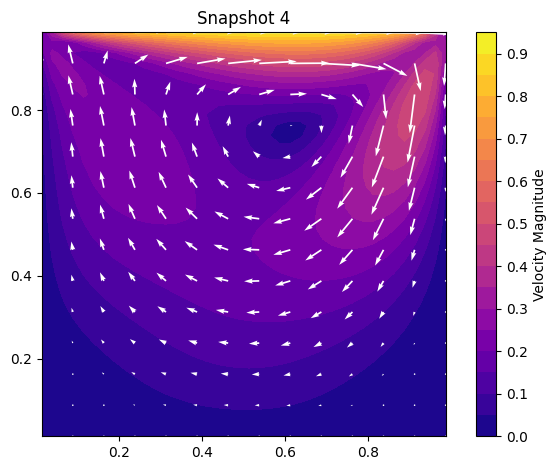

In [ ]:
def animate(results, draw_func, interval=None):
    plt.figure(figsize=(4,4))
    try:
        for t, state in results:
            plt.clf()
            draw_func(state, t)
            plt.tight_layout()
            plt.show()

            if interval:
                sleep(interval)

            clear_output(wait=True)

        # final frame
        plt.clf()
        draw_func(state, t)
        plt.tight_layout()
        plt.show()

    except KeyboardInterrupt:
        pass
results = list(enumerate(snapshots))

def draw_cfd(ds, t):
    X = ds.X.values
    Y = ds.Y.values
    U = ds.U.values
    V = ds.V.values
    vel = ds.velmag.values
    plt.contourf(X, Y, vel, levels=20, cmap="plasma")
    plt.colorbar(label="Velocity Magnitude")

    plt.quiver(
        X[::3, ::3], Y[::3, ::3],
        U[::3, ::3], V[::3, ::3],
        color="white", scale=5
    )

    plt.title(f"Snapshot {t}")
    plt.gca().set_aspect("equal")

animate(results, draw_cfd, interval=0.1)
